# Assignment 6

Making sure all the right packages are installed and the environment is set up correctly for deep learning procedures. Going through all the boxes in chapter 10.9.

In [49]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots

from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

from ISLP import load_data
from ISLP.models import ModelSpec as MS

In [51]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

In [53]:
from torchmetrics import MeanAbsoluteError, R2Score
from torchinfo import summary
from torchvision.io import read_image

In [55]:
from pytorch_lightning import seed_everything 
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [57]:
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import Resize, Normalize, CenterCrop, ToTensor

In [59]:
from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers

In [61]:
from ISLP.torch.imdb import load_lookup, load_tensor, load_sparse, load_sequential

In [63]:
from glob import glob 
import json

# 10.9.1 Single Layer Network on Hitters Data

We will fit two linear models (least squares and lasso) and compare their performance to that of a neural network. For this comparison we will use mean absolute error on a validation dataset

In [66]:
Hitters = load_data('Hitters').dropna()
n = Hitters.shape[0]

In [68]:
#Setting up the model matrix and the response.

model = MS(Hitters.columns.drop('Salary'), intercept=False)
X = model.fit_transform(Hitters).to_numpy()
Y = Hitters['Salary'].to_numpy()

In [70]:
#Splitting the data into test and training, fixing the random state used by sklearn to do the split.

(X_train, X_test, Y_train, Y_test) = train_test_split(X, Y, test_size=1/3, random_state=1)

In [72]:
#Fitting a linear model and evaluating test error directly

hit_lm = LinearRegression().fit(X_train, Y_train) 
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test- Y_test).mean()

np.float64(259.71528833146266)

In [74]:
#Fitting a LASSO with sklearn. Evaluating it directly.

scaler = StandardScaler(with_mean=True, with_std=True)
lasso = Lasso(warm_start=True, max_iter=30000)
standard_lasso = Pipeline(steps=[('scaler', scaler), ('lasso', lasso)])

X_s = scaler.fit_transform(X_train)
n = X_s.shape[0]
lam_max = np.fabs(X_s.T.dot(Y_train- Y_train.mean())).max() / n
param_grid = {'alpha': np.exp(np.linspace(0, np.log(0.01), 100)) * lam_max}

#Cross-validation
cv = KFold(10, shuffle=True, random_state=1)
grid = GridSearchCV(lasso, param_grid, cv=cv, scoring='neg_mean_absolute_error')
grid.fit(X_train, Y_train);

#Evaluation
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test- Y_test).mean()

print(np.fabs(Yhat_test - Y_test).mean())

257.23820107994993


###  Specifying a Network: Classes and Inheritance

To fit the neural network, we first set up a model structure that describes the network. Doing so requires us to define new classes specific to the mode we wish to fit.

In [76]:
 class HittersModel(nn.Module):
     def __init__(self, input_size):
         super(HittersModel, self).__init__()
         self.flatten = nn.Flatten()
         self.sequential = nn.Sequential(
             nn.Linear(input_size, 50),
             nn.ReLU(),
             nn.Dropout(0.4),
             nn.Linear(50, 1))
     def forward(self, x):
         x = self.flatten(x)
         return torch.flatten(self.sequential(x))

In [77]:
hit_model = HittersModel(X.shape[1])

In [78]:
summary(hit_model, input_size=X_train.shape, col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

In [79]:
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t, Y_train_t)

In [80]:
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t, Y_test_t)

In [87]:
max_num_workers = rec_num_workers()

In [89]:
hit_dm = SimpleDataModule(hit_train, hit_test, batch_size=32, num_workers=min(4, max_num_workers), validation=hit_test)

In [91]:
hit_module = SimpleModule.regression(hit_model, metrics={'mae':MeanAbsoluteError()})

In [101]:
from pytorch_lightning.loggers import CSVLogger
hit_logger = CSVLogger('logs', name='hitters')

In [105]:
from pytorch_lightning import Trainer
hit_trainer = Trainer(deterministic=True, max_epochs=50, log_every_n_steps=5, logger=hit_logger, callbacks=[ErrorTracker()])
hit_trainer.fit(hit_module, datamodule=hit_dm)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | HittersModel | 1.1 K  | train
1 | loss  | MSELoss      | 0      | train
-----------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 6/6 [00:06<00:00,  0.96it/s, v_num=0]             
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 6/6 [00:00<00:00, 121.49it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 6/6 [00:00<00:00, 126.66it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 6/6 [00:00<00:00, 138.44it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 6/6 [00:00<00:00, 132.20it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 6/6 [00:00<00:00, 138.38it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 6/6 [00:00<00:00, 127.25it/s, v_num=0]       
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 6/6 [00:00<00:00, 75.62it/s, v_num=0]        
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 6/6 [00:00<00:00, 98.39it

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 68.72it/s, v_num=0]


In [109]:
#Evaluating performance of neural network

hit_trainer.test(hit_module, datamodule=hit_dm)

Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 81.50it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss              104098.546875
        test_mae            229.50112915039062
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 104098.546875, 'test_mae': 229.50112915039062}]

In [119]:
#Retrieve logged summaries

hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)

In [127]:
#Plot function

def summary_plot(results, ax, col='loss', valid_legend='Validation',
 training_legend='Training', ylabel='Loss', fontsize=20):
 for (column, color, label) in zip([f'train_{col}_epoch', f'valid_{col}'], ['black', 'red'], [training_legend, valid_legend]):
     results.plot(x='epoch', y=column, label=label, marker='o', color=color, ax=ax)
 ax.set_xlabel('Epoch')
 ax.set_ylabel(ylabel)
 return ax

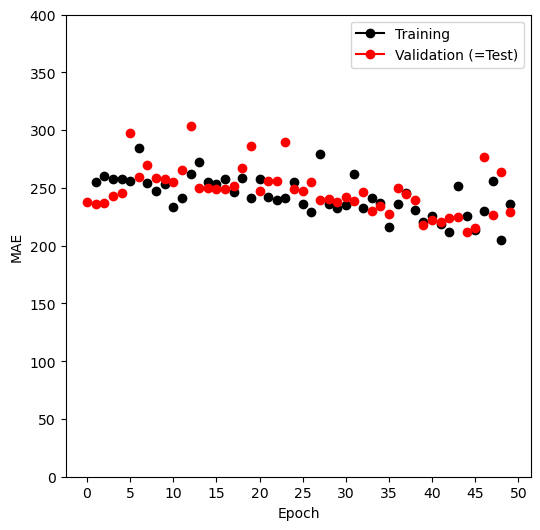

In [131]:
#Setting up axes, using function to plot MAE
fig, ax = subplots(1, 1, figsize=(6, 6)) 
ax = summary_plot(hit_results, ax, col='mae', ylabel='MAE', valid_legend='Validation (=Test)')
ax.set_ylim([0, 400])
ax.set_xticks(np.linspace(0, 50, 11).astype(int));

In [135]:
#Prediction and evaluation of neural network
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t- preds).mean()

tensor(229.5011, grad_fn=<MeanBackward0>)

In [139]:
#Cleanup -- kill all processes

del(Hitters, hit_model, hit_dm, hit_logger, hit_test, hit_train, X, Y, X_test, X_train, Y_test, Y_train, X_test_t, Y_test_t, hit_trainer, hit_module)

NameError: name 'Hitters' is not defined

#10.9.2 Multilayer Network on the MNIST Digit Data

In [141]:
#Retrieve datasets for test and training

(mnist_train , mnist_test) = [MNIST(root='data', train=train , download=True , transform=ToTensor ())
for train in [True , False ]]
mnist_train

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.84MB/s]


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 259kB/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw



Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [143]:
#Splitting dataset into train and test, reserving 20% for validation

mnist_dm = SimpleDataModule(mnist_train , mnist_test , validation =0.2, num_workers=max_num_workers , batch_size =256)

In [153]:
#Sneaking a peek of 2 batches

for idx , (X_ ,Y_) in enumerate(mnist_dm.train_dataloader ()):
    print('X: ', X_.shape)
    print('Y: ', Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])
X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])


In [163]:
#Specifying neural network

class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel , self).__init__ ()
        self.layer1 = nn.Sequential(nn.Flatten (), nn.Linear (28*28 , 256), nn.ReLU(), nn.Dropout (0.4))
        self.layer2 = nn.Sequential(nn.Linear (256, 128), nn.ReLU(), nn.Dropout (0.3))
        self._forward = nn.Sequential(self.layer1 , self.layer2 , nn.Linear (128, 10))
    def forward(self , x):
        return self._forward(x)

In [159]:
mnist_model = MNISTModel ()

In [161]:
mnist_model(X_).size()

torch.Size([256, 10])

In [167]:
summary(mnist_model , input_data=X_ , col_names =['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

In [177]:
mnist_module = SimpleModule.classification(mnist_model, num_classes=10)
mnist_logger = CSVLogger('logs', name='MNIST')

In [179]:
#Supplying data, fitting model

mnist_trainer = Trainer(deterministic=True, max_epochs =30, logger=mnist_logger, callbacks =[ ErrorTracker ()])
mnist_trainer.fit(mnist_module, datamodule=mnist_dm)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNISTModel       | 235 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
235 K     Trainable params
0         Non-trainable params
235 K     Total params
0.941     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 188/188 [00:03<00:00, 58.14it/s, v_num=0]         
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 188/188 [00:02<00:00, 65.49it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 188/188 [00:04<00:00, 43.78it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 188/188 [00:03<00:00, 60.04it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 188/188 [00:03<00:00, 60.49it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 188/188 [00:03<00:00, 54.56it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 188/188 [00:04<00:00, 45.77it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 188/188 [00:03<00:00, 59.09it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 188/188 [00:03<00:

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:03<00:00, 49.29it/s, v_num=0]


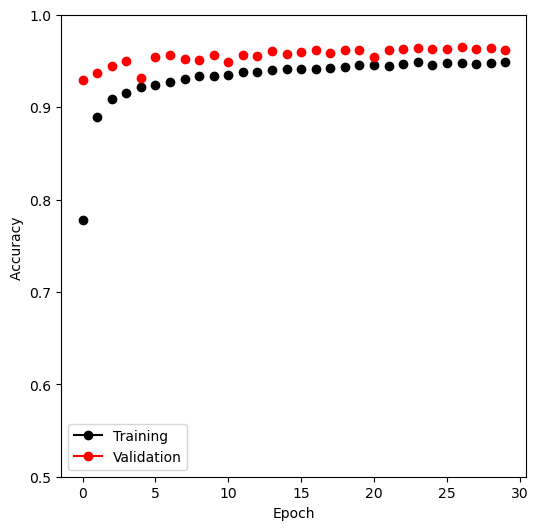

In [181]:
#Plotting accuracy

mnist_results = pd.read_csv(mnist_logger.experiment.metrics_file_path)
fig , ax = subplots (1, 1, figsize =(6, 6))
summary_plot(mnist_results, ax, col='accuracy', ylabel='Accuracy')
ax.set_ylim ([0.5 , 1])
ax.set_ylabel('Accuracy ')
ax.set_xticks(np.linspace (0, 30, 7).astype(int));

In [183]:
#How did we do? Evaluation.

mnist_trainer.test(mnist_module, datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 88.08it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy          0.96670001745224
        test_loss           0.14566123485565186
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.14566123485565186, 'test_accuracy': 0.96670001745224}]

In [187]:
#Getting into some regression. Multinomial logistic regression model for MNIST

class MNIST_MLR(nn.Module):
    def __init__(self):
        super(MNIST_MLR , self).__init__ ()
        self.linear = nn.Sequential(nn.Flatten (), nn.Linear (784, 10))
    def forward(self , x):
        return self.linear(x)
mlr_model = MNIST_MLR ()
mlr_module = SimpleModule.classification(mlr_model, num_classes=10)
mlr_logger = CSVLogger('logs', name='MNIST_MLR')

In [189]:
#Fitting the logistic regression model
mlr_trainer = Trainer(deterministic=True, max_epochs =30, callbacks =[ ErrorTracker ()])
mlr_trainer.fit(mlr_module, datamodule=mnist_dm)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\catba\anaconda3\envs\islp\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNIST_MLR        | 7.9 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---

Epoch 0: 100%|██████████| 188/188 [00:06<00:00, 28.08it/s, v_num=0]         
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 188/188 [00:05<00:00, 32.37it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 188/188 [00:07<00:00, 24.65it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 188/188 [00:04<00:00, 38.66it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 188/188 [00:05<00:00, 35.32it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 188/188 [00:05<00:00, 36.28it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 188/188 [00:05<00:00, 34.45it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 188/188 [00:05<00:00, 31.50it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 188/188 [00:04<00:

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:06<00:00, 29.86it/s, v_num=0]


In [191]:
#Drumroll... let's see the results!

mlr_trainer.test(mlr_module, datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 51.23it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9175999760627747
        test_loss           0.3366289436817169
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.3366289436817169, 'test_accuracy': 0.9175999760627747}]

In [193]:
#Cleaning is the most important part of the job.

del(mnist_test, mnist_train, mnist_model, mnist_dm, mnist_trainer, mnist_module, mnist_results, mlr_model, mlr_module, mlr_trainer)

#10.9.3 Convolutional Neural Networks

Now we are fitting a CNN to the CIFAR100 data, which is arranged similarly to the MNIST we worked with in the previous assignment.

In [195]:
#Downloading the dataset

(cifar_train, cifar_test) = [CIFAR100(root="data", train=train, download=True)
for train in [True, False]]

100%|██████████| 169M/169M [00:15<00:00, 10.8MB/s] 


Extracting data\cifar-100-python.tar.gz to data
Files already downloaded and verified


In [197]:
transform = ToTensor ()
cifar_train_X = torch.stack ([ transform(x) for x in cifar_train.data])
cifar_test_X = torch.stack ([ transform(x) for x in cifar_test.data])
cifar_train = TensorDataset(cifar_train_X, torch.tensor(cifar_train.targets))
cifar_test = TensorDataset(cifar_test_X, torch.tensor(cifar_test.targets))

In [201]:
#Creating data module

cifar_dm = SimpleDataModule(cifar_train, cifar_test, validation =0.2, num_workers=max_num_workers, batch_size =128)

In [203]:
#Looking at the shape

for idx , (X_ ,Y_) in enumerate(cifar_dm.train_dataloader ()):
    print('X: ', X_.shape)
    print('Y: ', Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])
X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])


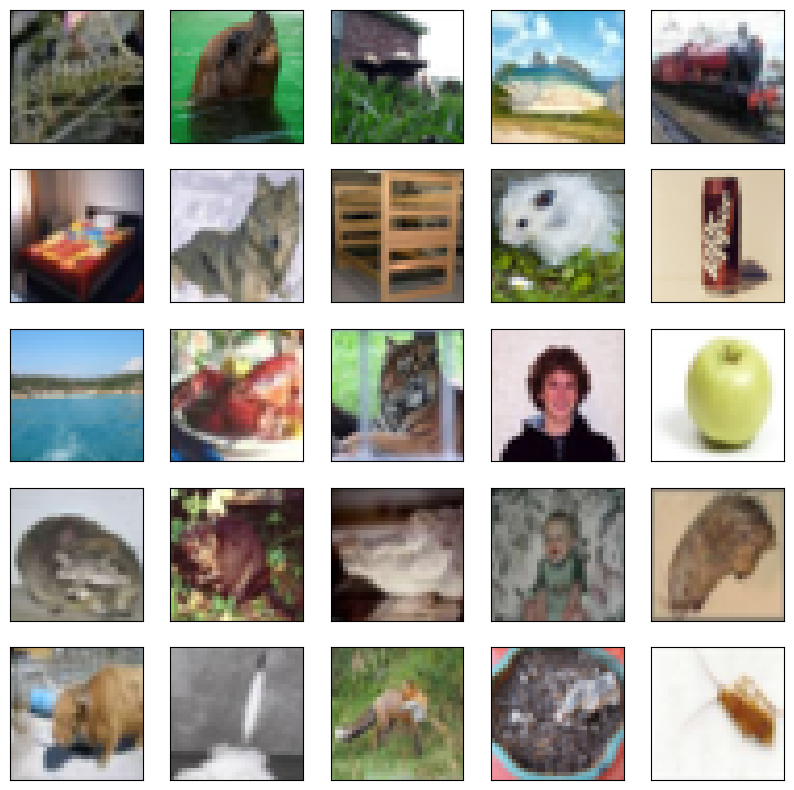

In [205]:
#Having a look at the images

fig, axes = subplots (5, 5, figsize =(10 ,10))
rng = np.random.default_rng (4)
indices = rng.choice(np.arange(len(cifar_train)), 25, replace=False).reshape ((5 ,5))

for i in range (5):
    for j in range (5):
        idx = indices[i,j]
        axes[i,j]. imshow(np.transpose(cifar_train[idx][0], [1,2,0]), interpolation=None)
        axes[i,j]. set_xticks ([])
        axes[i,j]. set_yticks ([])

In [211]:
#Specifying a moderately sized CNN with several layers of convolution, ReLU and max-pooling steps.

class BuildingBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super(BuildingBlock , self).__init__ ()
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size =(3, 3), padding='same')
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size =(2, 2))
    def forward(self , x):
        return self.pool(self.activation(self.conv(x)))

In [213]:
#Fitting with a generic trainer

class CIFARModel(nn.Module):
    def __init__(self):
        super(CIFARModel , self).__init__ ()
        sizes = [(3 ,32), (32 ,64), (64 ,128), (128 ,256)]
        self.conv = nn.Sequential (*[ BuildingBlock(in_ , out_)
            for in_ , out_ in sizes ])
        self.output = nn.Sequential(nn.Dropout (0.5), nn.Linear (2*2*256, 512), nn.ReLU(), nn.Linear (512, 100))
    def forward(self , x):
        val = self.conv(x)
        val = torch.flatten(val , start_dim =1)
        return self.output(val)

In [215]:
#Building the model and getting a summary

cifar_model = CIFARModel ()
summary(cifar_model, input_data=X_, col_names =['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CIFARModel                               [128, 3, 32, 32]          [128, 100]                --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 256, 2, 2]          --
│    └─BuildingBlock: 2-1                [128, 3, 32, 32]          [128, 32, 16, 16]         --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 32, 32, 32]         896
│    │    └─ReLU: 3-2                    [128, 32, 32, 32]         [128, 32, 32, 32]         --
│    │    └─MaxPool2d: 3-3               [128, 32, 32, 32]         [128, 32, 16, 16]         --
│    └─BuildingBlock: 2-2                [128, 32, 16, 16]         [128, 64, 8, 8]           --
│    │    └─Conv2d: 3-4                  [128, 32, 16, 16]         [128, 64, 16, 16]         18,496
│    │    └─ReLU: 3-5                    [128, 64, 16, 16]         [128, 64, 16, 16]         --
│    │    └─MaxPool2d: 3-6    

In [223]:
cifar_optimizer = RMSprop(cifar_model.parameters (), lr =0.001)
cifar_module = SimpleModule.classification(cifar_model, optimizer=cifar_optimizer, num_classes=100)
cifar_logger = CSVLogger('logs', name='CIFAR100')

In [225]:
cifar_trainer = Trainer(deterministic=True, max_epochs =30, logger=cifar_logger, callbacks =[ErrorTracker ()])
cifar_trainer.fit(cifar_module, datamodule=cifar_dm)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | CIFARModel       | 964 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.858     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 313/313 [00:59<00:00,  5.26it/s, v_num=0]         
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 313/313 [00:54<00:00,  5.69it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 313/313 [00:54<00:00,  5.73it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 313/313 [00:57<00:00,  5.41it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 313/313 [00:56<00:00,  5.53it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 313/313 [01:02<00:00,  5.03it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 313/313 [00:56<00:00,  5.58it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 313/313 [00:56<00:00,  5.55it/s, v_num=0]     
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 313/313 [01:04<00:

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 313/313 [01:09<00:00,  4.47it/s, v_num=0]


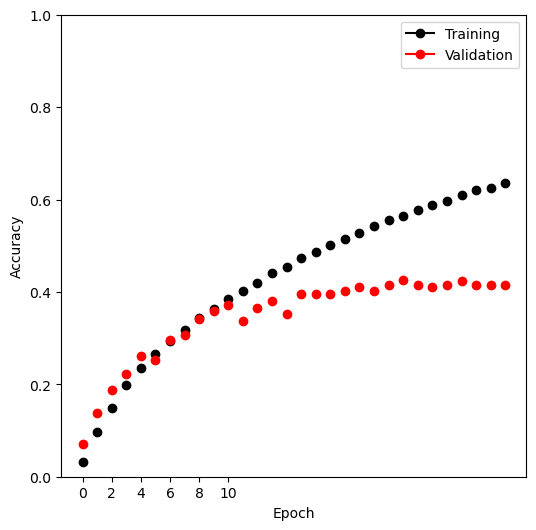

In [229]:
#Plotting the validation and training accuracy

log_path = cifar_logger.experiment.metrics_file_path
cifar_results = pd.read_csv(log_path)
fig , ax = subplots (1, 1, figsize =(6, 6))
summary_plot(cifar_results, ax, col='accuracy', ylabel='Accuracy')
ax.set_xticks(np.linspace (0, 10, 6).astype(int))
ax.set_ylabel('Accuracy')
ax.set_ylim ([0, 1]);

In [231]:
#Evaluating the model 

cifar_trainer.test(cifar_module, datamodule=cifar_dm)

Testing DataLoader 0: 100%|██████████| 79/79 [00:04<00:00, 16.09it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.4165000021457672
        test_loss           2.4326930046081543
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.4326930046081543, 'test_accuracy': 0.4165000021457672}]

In [239]:
#I'm using Windows and only training on CPU, so this piece of code doesn't apply.

try:
    for name , metric in cifar_module.metrics.items ():
        cifar_module.metrics[name] = metric.to('mps')
    cifar_trainer_mps = Trainer(accelerator='mps', deterministic=True, max_epochs =30)
    cifar_trainer_mps.fit(cifar_module, datamodule=cifar_dm)
    cifar_trainer_mps.test(cifar_module, datamodule=cifar_dm)
except Exception as e:
    print("An error occurred:", e)

An error occurred: PyTorch is not linked with support for mps devices


# 10.9.4 Using Pretrained CNN Models

In this exercise we are using a pretrained CNN, ResNet-50, for classification of natural images. ResNet-50 incorporates 50 bottleneck residual blocks, arranged in a stacked manner. The early layers of the network feature conventional convolutional and pooling layers to preprocess the image before it undergoes further processing by the residual blocks. 

We will read in the images, and convert them into the array format expected by the torch software to match the specifications in ResNet-50. The conversion involves a resize, a crop and then a predefined standardization for each of the three channels.

In [255]:
#Reading in and preprocessing images

resize = Resize ((232 ,232))
crop = CenterCrop (224)
normalize = Normalize ([0.485 ,0.456 ,0.406], [0.229 ,0.224 ,0.225])
imgfiles = sorted ([f for f in glob('book_images/*')])
imgs = torch.stack ([torch.div(crop(resize(read_image(f))), 255)
    for f in imgfiles ])
imgs = normalize(imgs)
imgs.size()

torch.Size([5, 3, 224, 224])

In [257]:
#Setting up the 50 layered pretrained network

resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
summary(resnet_model, input_data=imgs, col_names =['input_size', 'output_size', 'num_params'])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\catba/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 30.0MB/s]


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [5, 3, 224, 224]          [5, 1000]                 --
├─Conv2d: 1-1                            [5, 3, 224, 224]          [5, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [5, 64, 112, 112]         [5, 64, 112, 112]         128
├─ReLU: 1-3                              [5, 64, 112, 112]         [5, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [5, 64, 112, 112]         [5, 64, 56, 56]           --
├─Sequential: 1-5                        [5, 64, 56, 56]           [5, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [5, 64, 56, 56]           [5, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [5, 64, 56, 56]           [5, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [5, 64, 56, 56]           [5, 64, 56, 56]           128
│    │    └─ReLU: 3-3      

In [259]:
#Setting the mode to eval so the model is ready to predict new data

resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [261]:
#Feeding our images through the fitted network

img_preds = resnet_model(imgs)

In [265]:
#Computing probabilities

img_probs = np.exp(np.asarray(img_preds.detach ()))
img_probs /= img_probs.sum (1)[:,None]

In [269]:
#Downloading index file associated with imagenet

labs = json.load(open('imagenet_class_index.json'))
class_labels = pd.DataFrame ([( int(k), v[1]) for k, v in labs.items ()], columns =['idx', 'label'])
class_labels = class_labels.set_index('idx')
class_labels = class_labels.sort_index ()

In [273]:
#Constructing a dataframe with the three most likely classes for the images

for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df['prob'] = img_probs[i]
    img_df = img_df.sort_values(by='prob', ascending=False)[:3]
    print(f'Image: {imgfile}')
    print(img_df.reset_index().drop(columns =['idx']))

Image: book_images\Cape_Weaver.jpg
      label      prob
0   jacamar  0.297500
1     macaw  0.068107
2  lorikeet  0.051104
Image: book_images\Hawk_Fountain.jpg
            label      prob
0            kite  0.184716
1           robin  0.084018
2  great_grey_owl  0.061267
Image: book_images\Hawk_cropped.jpg
            label      prob
0            kite  0.453834
1  great_grey_owl  0.015914
2             jay  0.012210
Image: book_images\Lhasa_Apso.jpg
             label      prob
0            Lhasa  0.260317
1         Shih-Tzu  0.097195
2  Tibetan_terrier  0.032819
Image: book_images\Sleeping_Cat.jpg
         label      prob
0  Persian_cat  0.163070
1        tabby  0.074143
2    tiger_cat  0.042578


In [275]:
#Cleanliness is next to godliness

del(cifar_test, cifar_train, cifar_dm, cifar_module, cifar_logger, cifar_optimizer, cifar_trainer)

# 2. Reflection

Reflect on what you see in each of the three training performance curves. E.g. (for each training) does the model seem to be training well? Is it converging? Is it overfitting/underfitting? If you saw this in a real-life scenario, what measures would you try to make the model better? If you don't know where to start in interpreting this you can as always send me an email, but I also recommend trying to use GPT UiO to see if it can help you get started. 

ResNet-50 is pretrained, so I assume you want me to evaluate the other models in this chapter. 
pretrained. Is it converging? Is it overfitting/underfitting? What measures to make it better?

#### Hitter’s model
This model is used to predict wages of baseball hitters. The loss curve plot looks like a scatterplot with a very slight downward trend, indicating that it does learn a little bit, but the model is underfitted. It does not converge. 
The MAE is ~229 (as in 229000 USD), which means that the prediction is off by a good margin most of the time (median salary for hitters is ~425000 USD in the dataset). However, the one layered neural network did perform better than both the LASSO (~257) and the linear model (~259).
To improve, I would try increasing the model complexity (e.g., adding more layers or neurons) or tuning hyperparameters. Regularization could also be explored to prevent potential overfitting if the model is made more complex.

#### MNIST
This model is used for number classification (10 classes). In the plot we can see that the training and validation does converge. Instead of a mean standard error we have an accuracy score (~0,97 and a loss function (~0,15). With an accuracy of 97% we can say that this model performs very well. With such a high accuracy score I would be worried that the model is overfitted, but since the training and validation scores converge it is probably performing well and could be generalized to other samples. 
We also fitted a logistic regression model to the MNIST data, and it performed very well with a loss function of ~0,33 and a test accuracy of ~92%. Both models predict the numbers well, but the neural network outperforms the logistic regression model.

#### Convolutional neural network (CNN)
This multilayered model is used for image classification (100 classes). In the plot we can see that the accuracy scores of the training and validation converge up to a point, but then the training data increases in accuracy and the validation stays at about 0.4. When this happens it is a sign that our model is overfitted. The test loss is ~2.4 and the accuracy lands at ~0.42. 
To address overfitting, I would try stronger regularization (L2), data augmentation, or early stopping. Additionally, simplifying the model or increasing the amount of training data could help.